In [8]:
import sys
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import re
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, combine_pvalues
from scipy.stats import chi2_contingency
import pysam
from tqdm import tqdm
from scipy.optimize import curve_fit


plt.rcdefaults()
# mpl.rcParams[''] = 42
# mpl.rcParams['font.size'] = 14

plt.style.use('default')

def theme_classic():
    mpl.rcParams.update({
        'pdf.fonttype': 42,
        'font.size': 12,
        'axes.grid': False,
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.0,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.direction': 'out',
        'ytick.direction': 'out'
    })

theme_classic()

sys.path.insert(0, '/private/groups/brookslab/gabai/tools/epiflair/src/')
from plot import *
import importlib
importlib.reload(sys.modules['plot'])

<module 'plot' from '/private/groups/brookslab/gabai/tools/epiflair/src/plot.py'>

## Figure 2G, Figure 2H

In [10]:
inpath = '../data/chrom/'

In [11]:
def sin_model(x, A, phi, C):
    P = 180  # fixed nucleosome period
    return A * np.sin(2*np.pi*x/P + phi) + C

0.02847463395582661
0.03782842202947789
0.08667723208395894
0.09264186072889236


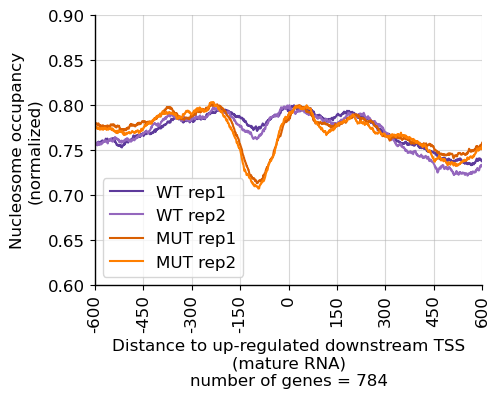

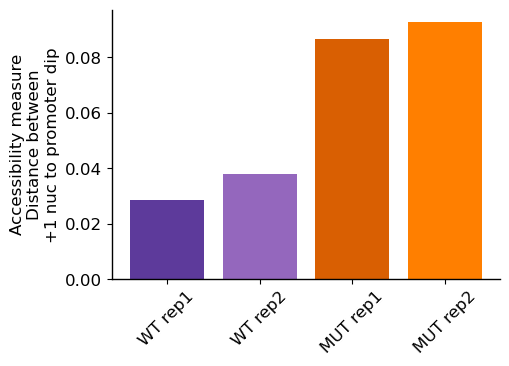

In [19]:
fig, ax1 = plt.subplots(figsize=(5, 3.5))
cmap = ['#5D3A9B', '#9467bd', '#d95f02', '#ff7f00']
ys18_rep1_agg = f'{inpath}260309_teloprime_ym209_rep1_downstream_Up_in_MUT_ys18_rep1_aggregate_score.tsv'
ys18_rep2_agg = f'{inpath}260309_teloprime_ym209_rep1_downstream_Up_in_MUT_ys18_rep2_aggregate_score.tsv'
ym209_rep1_agg = f'{inpath}260309_teloprime_ym209_rep1_downstream_Up_in_MUT_ym209_rep1_aggregate_score.tsv'
ym209_rep2_agg = f'{inpath}260309_teloprime_ym209_rep1_downstream_Up_in_MUT_ym209_rep2_aggregate_score.tsv'
allagg = [ys18_rep1_agg, ys18_rep2_agg, ym209_rep1_agg, ym209_rep2_agg]

hw = int(2000/2)
space=150
labels = ['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']
dists = []
amplitudes = []
k = 1
for i in range(len(allagg)):
    with open(allagg[i], 'r') as infile:
        agg_scores = []
        for line in infile:
            line = line.strip().split('\t')
            agg_scores.append(float(line[k]))
        
        # dist between peak to dip
        peak = max(agg_scores[900:1100])
        dip = min(agg_scores[900:1100])
        dist = 0.8 - peak
        agg_scores_norm = [s + dist for s in agg_scores]
        print(peak-dip)
        dists.append(peak-dip)

        x = np.arange(-hw, hw+1)
        y = np.array(agg_scores_norm)
        
        # magnitute
        mask = (x > 0) & (x < 800)
        x_fit = x[mask]
        y_fit = y[mask]
        
        popt, _ = curve_fit(sin_model,x_fit,y_fit, p0=[0.1, 0, 0.5])
        
        A_fit = abs(popt[0])
        amplitudes.append(A_fit)

        ax1.plot(np.arange(-hw, hw+1), agg_scores_norm, label = labels[i], color=cmap[i], alpha=1)

x_ticks = np.concatenate((np.flip(np.arange(0, -hw-1, -space)[1:]), np.arange(0, hw+1, space)), axis=0)
ax1.grid(alpha=0.5)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_ticks, rotation='vertical')

ax1.set_xlabel(f"Distance to up-regulated downstream TSS\n(mature RNA)\nnumber of genes = {784}")
ax1.set_ylabel('Nucleosome occupancy\n(normalized)')
ax1.set_ylim(0.6, 0.9)
ax1.set_xlim(-600, 600)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.savefig('../figures/Figure2G_agg_de_downstream_tss_mature.pdf', bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(5, 3.5))
left = 1
for i in range(len(dists)):
    plt.bar(left, dists[i], label = labels[i], color=cmap[i])
    left += 1
plt.xticks(np.arange(1, len(dists)+1), labels, rotation = 45)
plt.ylabel('Accessibility measure\nDistance between\n+1 nuc to promoter dip')
plt.savefig('../figures/Figure2H_distance_between_peak_dip_de_downstream_tss_mature.pdf', bbox_inches='tight')

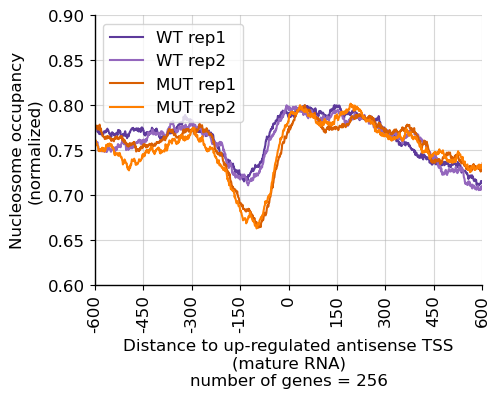

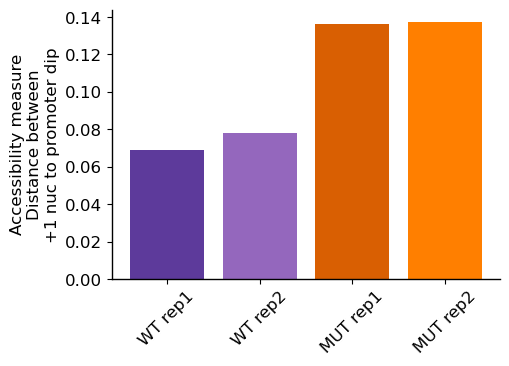

In [18]:
fig, ax1 = plt.subplots(figsize=(5, 3.5))
cmap = ['#5D3A9B', '#9467bd', '#d95f02', '#ff7f00']
ys18_rep1_agg = f'{inpath}260309_teloprime_ym209_rep1_antisense_Up_in_MUT_ys18_rep1_aggregate_score.tsv'
ys18_rep2_agg = f'{inpath}260309_teloprime_ym209_rep1_antisense_Up_in_MUT_ys18_rep2_aggregate_score.tsv'
ym209_rep1_agg = f'{inpath}260309_teloprime_ym209_rep1_antisense_Up_in_MUT_ym209_rep1_aggregate_score.tsv'
ym209_rep2_agg = f'{inpath}260309_teloprime_ym209_rep1_antisense_Up_in_MUT_ym209_rep2_aggregate_score.tsv'
allagg = [ys18_rep1_agg, ys18_rep2_agg, ym209_rep1_agg, ym209_rep2_agg]

hw = int(2000/2)
space=150
labels = ['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']
dists = []
amplitudes = []
k = 1
for i in range(len(allagg)):
    with open(allagg[i], 'r') as infile:
        agg_scores = []
        for line in infile:
            line = line.strip().split('\t')
            agg_scores.append(float(line[k]))
        
        # dist between peak to dip
        peak = max(agg_scores[900:1100])
        dip = min(agg_scores[900:1100])
        dist = 0.8 - peak
        agg_scores_norm = [s + dist for s in agg_scores]
        dists.append(peak-dip)

        x = np.arange(-hw, hw+1)
        y = np.array(agg_scores_norm)
        
        # magnitute
        mask = (x > 0) & (x < 800)
        x_fit = x[mask]
        y_fit = y[mask]
        
        popt, _ = curve_fit(sin_model,x_fit,y_fit, p0=[0.1, 0, 0.5])
        
        A_fit = abs(popt[0])
        amplitudes.append(A_fit)

        ax1.plot(np.arange(-hw, hw+1), agg_scores_norm, label = labels[i], color=cmap[i], alpha=1)

x_ticks = np.concatenate((np.flip(np.arange(0, -hw-1, -space)[1:]), np.arange(0, hw+1, space)), axis=0)
ax1.grid(alpha=0.5)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_ticks, rotation='vertical')

ax1.set_xlabel(f"Distance to up-regulated antisense TSS\n(mature RNA)\nnumber of genes = {256}")
ax1.set_ylabel('Nucleosome occupancy\n(normalized)')
ax1.set_ylim(0.6, 0.9)
ax1.set_xlim(-600, 600)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.savefig('../figures/Figure2I_agg_de_antisense_tss_mature.pdf', bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(5, 3.5))
left = 1
for i in range(len(dists)):
    plt.bar(left, dists[i], label = labels[i], color=cmap[i])
    left += 1
plt.xticks(np.arange(1, len(dists)+1), labels, rotation = 45)
plt.ylabel('Accessibility measure\nDistance between\n+1 nuc to promoter dip')
plt.savefig('../figures/Supp_distance_between_peak_dip_de_antisense_tss_mature.pdf', bbox_inches='tight')

## Figure2J, 2K

In [3]:
genome = '../data/ref/sacCer3.fa'

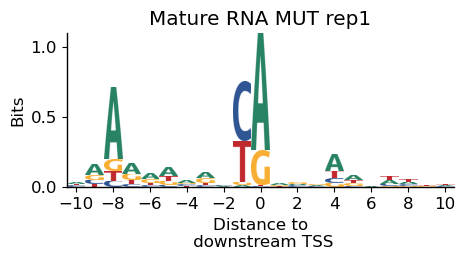

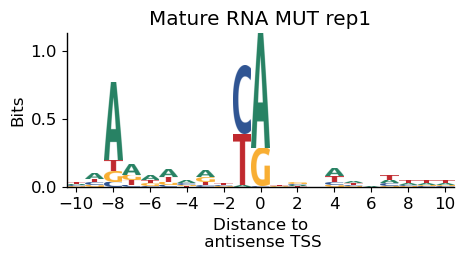

In [4]:
mature_tss = '../data/rna/matureRNA/tss_tts_annot/251027_teloprime_genomic_alignment_ym209_rep1_tss.bed'


plotMotif_bed(genome, mature_tss, outpath= '../figures/', 
                   title = 'Mature RNA MUT rep1', 
          prefix = f'Figure2J_mature_motif_ym209_rep1_downstream', stranded=True,
          annot = 'downstream', geneList = '', 
          extend = (10, 10), shift=0, center_name = 'downstream TSS', space = 2)


plotMotif_bed(genome, mature_tss, outpath= '../figures/', 
                   title = 'Mature RNA MUT rep1', 
          prefix = f'Figure2K_mature_motif_ym209_rep1_antisense', stranded=True,
          annot = 'antisense', geneList = '', 
          extend = (10, 10), shift=0, center_name = 'antisense TSS', space = 2)